## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
df = pd.read_csv("amostra_com_balanceamento/dataset_balanceado.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

Shape: (16457968, 24)
Memória: 15044 MB


## Entendimento dos dados

In [4]:
df.head(2)

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label,scenario
0,1540469302.5386,CGm6jB4dXK71ZDWUDh,192.168.1.132,58687,216.239.35.4,123,udp,-,0.114184,48,48,SF,-,-,0,Dd,1,76,1,76,-,benign,-,CTU-Honeypot-Capture-4-1
1,1540469197.4002,CnaDAG3n5r8eiG4su2,192.168.1.132,1900,239.255.255.250,1900,udp,-,160.367579,7536,0,S0,-,-,0,D,24,8208,0,0,-,benign,-,CTU-Honeypot-Capture-4-1


### Explicação das colunas

In [5]:
print(df.columns.tolist())

['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'label', 'detailed-label', 'scenario']


ts: Timestamp do início da conexão (Unix time)

uid: Identificador único da conexão gerado pelo Zeek

id.orig_h: IP de origem (quem iniciou a conexão)

id.orig_p: Porta de origem

id.resp_h: IP de destino (quem recebeu a conexão)

id.resp_p: Porta de destino

proto: Protocolo de transporte (tcp, udp, icmp)

service: Protocolo de aplicação detectado pelo Zeek (http, dns, ssh, etc.)

duration: Duração da conexão em segundos

orig_bytes: Bytes enviados pela origem

resp_bytes: Bytes enviados pelo destino em resposta

conn_state: Estado final da conexão (ex: SF = encerrada normalmente, S0 = sem resposta)

local_orig: Se a origem é uma máquina da rede local

local_resp: Se o destino é uma máquina da rede local

missed_bytes: Bytes perdidos/não capturados durante a conexão

history: Sequência de eventos da conexão em letras (ex: ShADadFf)

orig_pkts: Número de pacotes enviados pela origem

orig_ip_bytes: Total de bytes IP enviados pela origem (inclui cabeçalhos)

resp_pkts: Número de pacotes enviados pelo destino

resp_ip_bytes: Total de bytes IP enviados pelo destino (inclui cabeçalhos)

tunnel_parents: ????????

label: Variável alvo 1: Malicious ou Benign

detailed-label: Variável alvo 2: tipo específico do comportamento (DDoS, C&C, PortScan, etc.) ou - para benigno

scenario: Coluna adicionada por nós — identifica o cenário de origem do flow

### Tipos de cada coluna

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16457968 entries, 0 to 16457967
Data columns (total 24 columns):
 #   Column          Dtype  
---  ------          -----  
 0   ts              float64
 1   uid             str    
 2   id.orig_h       str    
 3   id.orig_p       int64  
 4   id.resp_h       str    
 5   id.resp_p       int64  
 6   proto           str    
 7   service         str    
 8   duration        str    
 9   orig_bytes      str    
 10  resp_bytes      str    
 11  conn_state      str    
 12  local_orig      str    
 13  local_resp      str    
 14  missed_bytes    int64  
 15  history         str    
 16  orig_pkts       int64  
 17  orig_ip_bytes   int64  
 18  resp_pkts       int64  
 19  resp_ip_bytes   int64  
 20  tunnel_parents  str    
 21  label           str    
 22  detailed-label  str    
 23  scenario        str    
dtypes: float64(1), int64(7), str(16)
memory usage: 2.9 GB


### Colunas a serem removidas inicialmente

In [7]:
# uid: ID único por conexão, sem padrão aprendível. Nao agrega em nada.
# ts: Timestamp específico da captura, não representa comportamento

# id.orig_h e id.resp_h: IP específico do dispositivo capturado em 2018-2019. O modelo aprenderia IPs concretos, não comportamentos - não generaliza para redes novas
# id.orig_p: Porta de origem é geralmente aleatória e não impacta no problema, é pouco informativa

# tunnel_parents: Descobrir o que é.

colunas_remover = ["uid", "ts", "id.orig_h", "id.resp_h", "id.orig_p"]

df = df.drop(columns=colunas_remover)

print(f"Colunas restantes ({len(df.columns)}):")
print(df.columns.tolist())

Colunas restantes (19):
['id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'label', 'detailed-label', 'scenario']


### Verificação de valores nulos ou ausentes

In [9]:
# Subistituinod o - por NaN para facilitar a análise de nulos
df = df.replace("-", pd.NA)

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(2)

resumo = pd.DataFrame({"quantidade": nulos, "percentual (%)": pct})
print(resumo.to_string())

                quantidade  percentual (%)
local_orig        16457968        100.0000
local_resp        16457968        100.0000
service           16426647         99.8100
tunnel_parents    15349379         93.2600
duration          11693325         71.0500
resp_bytes        11693325         71.0500
orig_bytes        11693325         71.0500
detailed-label     2464270         14.9700
history              32958          0.2000


1) **local_orig e local_resp**: Sempre foram '-' no dataset. O Zeek não determinou localidade para nenhuma conexão. Deverão ser removidas também.

2) **service:** É o protocolo da aplicação. A maioria das conexões é TCP/UDP genérico sem protocolo de aplicação. Vamos manter por enquanto

3) **tunnel_parents:** A maioria das conexões não usa tunelamento. Vamos remover também

4) **duration, orig_bytes, resp_bytes:** Essas colunas tem relação entre si. O numero de nulos ser o mesmo é coerente. Isso acontece porque conexões que nunca foram estabelecidas não têm duração nem bytes trocados. Já que existe a coluna conn_state, conseguimos saber o que é valor ausente de fato e o que realmente é Null. Vamos manter por enquanto.

In [10]:
# Removendo local_origin e local_resp por terem 100% de nulos
df = df.drop(columns=["local_orig", "local_resp", "tunnel_parents"])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16457968 entries, 0 to 16457967
Data columns (total 15 columns):
 #   Column          Dtype
---  ------          -----
 0   id.resp_p       int64
 1   proto           str  
 2   service         str  
 3   duration        str  
 4   orig_bytes      str  
 5   resp_bytes      str  
 6   conn_state      str  
 7   missed_bytes    int64
 8   history         str  
 9   orig_pkts       int64
 10  orig_ip_bytes   int64
 11  resp_pkts       int64
 12  resp_ip_bytes   int64
 13  label           str  
 14  detailed-label  str  
dtypes: int64(6), str(9)
memory usage: 1.8 GB


## Desbalanceamentos

### Distribuição da coluna label


label
Malicious    13993698
Benign        2462444
benign           1826
Name: count, dtype: int64



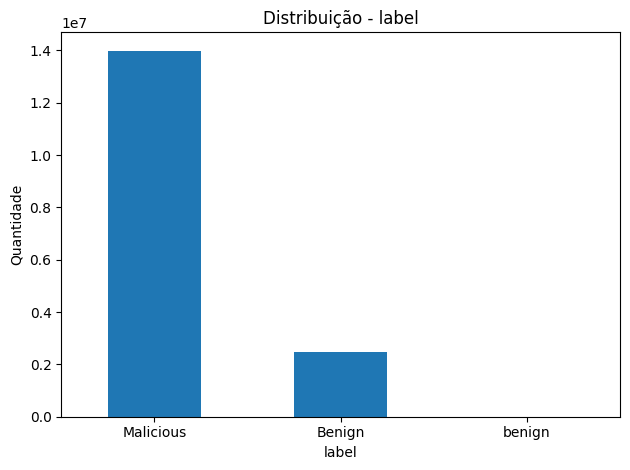

In [12]:
print(df["label"].value_counts())
print()

df["label"].value_counts().plot(kind="bar", title="Distribuição - label", rot=0)
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Distribuição da coluna detailed-label

detailed-label
PartOfAHorizontalPortScan           8452856
Okiru                               4018292
DDoS                                1455640
C&C-HeartBeat                         33673
C&C                                   21995
Attack                                 9398
C&C-PartOfAHorizontalPortScan           888
C&C-HeartBeat-Attack                    834
C&C-FileDownload                         53
C&C-Torii                                30
FileDownload                             18
C&C-HeartBeat-FileDownload               11
PartOfAHorizontalPortScan-Attack          5
Okiru-Attack                              3
C&C-Mirai                                 2



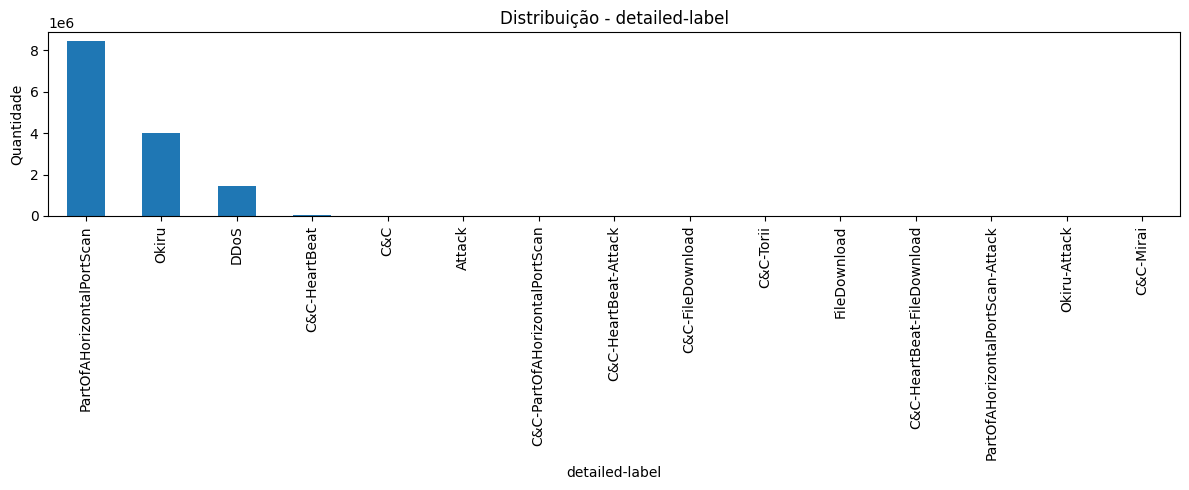

In [13]:
print(df["detailed-label"].value_counts().to_string())
print()

df["detailed-label"].value_counts().plot(
    kind="bar", title="Distribuição - detailed-label", figsize=(12, 5)
)
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Tratamentos

1) Agrupar por nome pode ser uma estratégia

2) Reduzir a quantidade de dados trabalhados (Undersampling nas classes dominantes)

3) Alguns modelos em o parametro class_weight="balanced". Pode ser útil futuramente. Pesquisar sobre

## Distribuição por cenário

In [14]:
print(df["scenario"].value_counts().to_string())

scenario
CTU-IoT-Malware-Capture-39-1    3678447
CTU-IoT-Malware-Capture-43-1    3366080
CTU-IoT-Malware-Capture-17-1    2732990
CTU-IoT-Malware-Capture-33-1    2722734
CTU-IoT-Malware-Capture-52-1     989065
CTU-IoT-Malware-Capture-36-1     682255
CTU-IoT-Malware-Capture-7-1      572735
CTU-IoT-Malware-Capture-35-1     522384
CTU-IoT-Malware-Capture-9-1      318913
CTU-IoT-Malware-Capture-49-1     270528
CTU-IoT-Malware-Capture-60-1     179051
CTU-IoT-Malware-Capture-48-1     169716
CTU-IoT-Malware-Capture-3-1      156103
CTU-IoT-Malware-Capture-1-1       50435
CTU-IoT-Malware-Capture-34-1      23145
CTU-IoT-Malware-Capture-8-1       10403
CTU-IoT-Malware-Capture-42-1       4426
CTU-IoT-Malware-Capture-21-1       3286
CTU-IoT-Malware-Capture-20-1       3209
CTU-Honeypot-Capture-5-1           1374
CTU-Honeypot-Capture-4-1            452
CTU-IoT-Malware-Capture-44-1        237


### Tratamento

1) Essa coluna deverá ser removida. Essa coluna fomos nós que criamos somente pra restreabilidade, não agrega em informação.

In [15]:
# Removendo a coluna scenario
df = df.drop(columns=["scenario"])

## Colunas categóricas

In [16]:
for col in ["proto", "service", "conn_state"]:
    print(f"\n{col}:")
    print(df[col].value_counts().head(15).to_string())


proto:
proto
tcp     16175231
udp       249779
icmp       32958

service:
service
dns     21352
ssh      6436
irc      2561
http      704
dhcp      173
ssl        95

conn_state:
conn_state
S0        15894064
RSTOS0      259608
OTH         233577
SF           37710
REJ          24993
RSTO          2797
S3            2484
RSTRH         1278
RSTR           788
SH             299
S2             181
S1             165
SHR             24


### Coluna history

In [18]:
print(df["history"].nunique())
print(df["history"].value_counts().head(20))

324
history
S            15672011
I              253262
D              222047
C              190727
Dd              27711
Sr              24774
DTT              7850
R                6333
ShAdDaFf         5445
ShAdDaf          2263
^c               1977
ShR              1506
^r               1277
ShADdfrFr        1030
^hR               952
ShADdafF          673
ShADadFf          516
ShAdDafF          341
F                 297
ShAdfDr           243
Name: count, dtype: int64


### Vamos criar uma feature aq

#### Tratamentos

1) Proto: One-Hot Encoding → vira 3 colunas binárias (proto_tcp, proto_udp, proto_icmp)

2) service: preencher nulos com "unknown" e aplicar One-Hot Encoding. dns, ssh, irc, http, dhcp, ssl, unknown -> 7 colunas binárias

3) conn_state: É muito informatico, mas são muitos grupos. Podemos agrupar em: no_reply, established, reset, rejected, other. Depois one-hot-encoding